# Category Intelligence — Retail Product Performance EDA
## Individual Notebook — Mulla Javeed

**Calibo AI Academy · Phase 1 · Mini Use Case 01 · Path 2 — KLU Batch**

| | |
|---|---|
| **Team** | Batch_12 |
| **Member** | Mulla Javeed |
| **Role** | Product Insights Analyst |
| **Sections owned** | Step 6.3 Top and Bottom Products by Category |

This notebook drills from category level to product level: the top two and bottom two products by revenue in each of the five categories, and the case for which category and products to challenge in the supplier review.

**Dataset:** `MUC01_Retail_Sales_Dataset.csv` — place it in the same folder as this notebook.
All figures here are calculated from that file and match the shared team notebook exactly.

*Role note: the assignment brief defines roles for teams of two or three. This team has four members,
so this allocation of the six required steps is our own internal split, not a structure prescribed by
the brief.*

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ---- House chart style: one palette and one labelling convention for the whole notebook ----
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (11, 6),
    "figure.dpi": 110,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

# Fixed category colours so every chart in the notebook reads the same way
CATEGORY_COLOURS = {
    "Electronics":    "#1f4e79",
    "Apparel":        "#c0504d",
    "Grocery":        "#4f8a3d",
    "Home & Kitchen": "#e08a1e",
    "Personal Care":  "#7b5ea7",
}
ACCENT = "#1f4e79"

def inr(x, decimals=2):
    """Format a rupee amount in business-readable units (Cr / L / plain)."""
    if abs(x) >= 1e7:
        return f"\u20b9{x/1e7:,.{decimals}f} Cr"
    if abs(x) >= 1e5:
        return f"\u20b9{x/1e5:,.{decimals}f} L"
    return f"\u20b9{x:,.0f}"

def rupee_axis(ax, scale=1e6, suffix=" Mn", decimals=1):
    """Apply rupee formatting to the y-axis of a chart."""
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f"\u20b9{v/scale:,.{decimals}f}{suffix}")
    )

print("Libraries loaded. Chart style set for the whole notebook.")

Libraries loaded. Chart style set for the whole notebook.


## Load the Dataset and Prepare Shared Fields

The same load-and-prepare step used in the team notebook, so this notebook runs standalone and
reproduces identical figures.

In [2]:
df = pd.read_csv("MUC01_Retail_Sales_Dataset.csv")

df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.to_period("M")
df["month_label"] = df["date"].dt.strftime("%b %Y")
df["day_of_week"] = df["date"].dt.day_name()

cat_mix = (df.groupby("category")
             .agg(Transactions=("transaction_id", "count"),
                  Units=("units_sold", "sum"),
                  Revenue=("revenue", "sum"))
             .sort_values("Revenue", ascending=False))
cat_mix["Revenue share %"] = (cat_mix["Revenue"] / cat_mix["Revenue"].sum() * 100).round(1)

monthly_category = (df.pivot_table(index="month", columns="category",
                                   values="revenue", aggfunc="sum").sort_index())
MONTH_ORDER = [p.strftime("%b %Y") for p in monthly_category.index]

print("Rows, Columns    :", df.shape)
print("Date range       :", df["date"].min().date(), "to", df["date"].max().date())
print("Categories       :", df["category"].nunique(), "| Products:", df["product_name"].nunique())
print("Null values      :", int(df.isnull().sum().sum()),
      "| Duplicate transaction IDs:", int(df["transaction_id"].duplicated().sum()))
print("Total revenue    :", inr(df["revenue"].sum()))

Rows, Columns    : (107836, 13)
Date range       : 2026-01-01 to 2026-06-30
Categories       : 5 | Products: 25
Null values      : 0 | Duplicate transaction IDs: 0
Total revenue    : ₹45.98 Cr


# Step 6.3 — Top and Bottom Products by Category

**Owner: [Member2Name] — Product Insights Analyst**

Category-level trends tell the Category Manager *where* the problem is. Product-level revenue tells
her *what* to put on the table in the meeting.

In [3]:
product_perf = (df.groupby(["category", "product_name"])
                  .agg(total_revenue=("revenue", "sum"),
                       units_sold=("units_sold", "sum"),
                       transactions=("transaction_id", "count"),
                       avg_unit_price=("unit_price", "mean"),
                       avg_discount_pct=("discount_pct", "mean"))
                  .reset_index())

product_perf["revenue_share_in_category_%"] = (
    product_perf["total_revenue"]
    / product_perf.groupby("category")["total_revenue"].transform("sum") * 100).round(2)

print("Products analysed:", len(product_perf), "across", product_perf["category"].nunique(), "categories")
product_perf.sort_values(["category", "total_revenue"], ascending=[True, False]).round(2).head(10)

Products analysed: 25 across 5 categories


,category,product_name,total_revenue,units_sold,transactions,avg_unit_price,avg_discount_pct,revenue_share_in_category_%
3,Apparel,Saree,14161864.63,7909,3078,1918.98,7.29,20.38
4,Apparel,T-Shirt,14099251.65,8028,3123,1893.89,7.23,20.29
1,Apparel,Jeans,13862749.46,7857,2985,1906.71,7.28,19.95
0,Apparel,Formal Shirt,13748976.91,7954,3082,1873.69,7.04,19.79
2,Apparel,Kurta,13606747.03,7708,3033,1902.15,7.09,19.58
5,Electronics,Headphones,47696053.99,2096,790,24043.63,7.04,21.06
6,Electronics,Laptop,46551078.39,2153,837,23421.77,7.54,20.55
7,Electronics,Mobile Phone,45654037.41,2077,796,23765.41,7.01,20.15
9,Electronics,Tablet,44744388.93,2069,820,23667.54,7.34,19.75
8,Electronics,Smart TV,41882166.21,1977,772,22514.20,6.92,18.49


In [4]:
# --- Consolidated top-2 / bottom-2 table for all five categories ---
rows = []
for cat in sorted(product_perf["category"].unique()):
    sub = product_perf[product_perf["category"] == cat].sort_values("total_revenue", ascending=False)
    for i, (_, r) in enumerate(sub.head(2).iterrows(), start=1):
        rows.append([cat, f"Top {i}", r["product_name"], r["total_revenue"], r["units_sold"]])
    bottom = sub.tail(2).sort_values("total_revenue")           # weakest first
    for i, (_, r) in enumerate(bottom.iterrows(), start=1):
        rows.append([cat, f"Bottom {i}", r["product_name"], r["total_revenue"], r["units_sold"]])

top_bottom = pd.DataFrame(rows, columns=["Category", "Rank", "Product",
                                         "Total Revenue (\u20b9)", "Units Sold"])
top_bottom["Total Revenue (\u20b9)"] = top_bottom["Total Revenue (\u20b9)"].round(2)

print("TOP 2 AND BOTTOM 2 PRODUCTS BY TOTAL REVENUE, BY CATEGORY (Jan-Jun 2026)")
top_bottom

TOP 2 AND BOTTOM 2 PRODUCTS BY TOTAL REVENUE, BY CATEGORY (Jan-Jun 2026)


,Category,Rank,Product,Total Revenue (₹),Units Sold
0,Apparel,Top 1,Saree,14161864.63,7909
1,Apparel,Top 2,T-Shirt,14099251.65,8028
2,Apparel,Bottom 1,Kurta,13606747.03,7708
3,Apparel,Bottom 2,Formal Shirt,13748976.91,7954
4,Electronics,Top 1,Headphones,47696053.99,2096
5,Electronics,Top 2,Laptop,46551078.39,2153
6,Electronics,Bottom 1,Smart TV,41882166.21,1977
7,Electronics,Bottom 2,Tablet,44744388.93,2069
8,Grocery,Top 1,Rice (5kg),8562171.86,28329
9,Grocery,Top 2,Dal (1kg),8488303.64,28026


In [5]:
# --- How far apart are the best and worst product inside each category? ---
spread = (product_perf.groupby("category")["total_revenue"]
          .agg(best="max", worst="min", category_total="sum"))
spread["Gap (\u20b9)"] = spread["best"] - spread["worst"]
spread["Worst as % of best"] = (spread["worst"] / spread["best"] * 100).round(1)
spread["Category total (\u20b9 Cr)"] = (spread["category_total"] / 1e7).round(2)

print("REVENUE SPREAD BETWEEN THE BEST AND WORST PRODUCT IN EACH CATEGORY")
print(spread[["Gap (\u20b9)", "Worst as % of best", "Category total (\u20b9 Cr)"]].round(2).to_string())

print("\nELECTRONICS - PRODUCT REVENUE BY MONTH (\u20b9 Lakh), the declining category from Step 6.2")
elec_monthly = (df[df["category"] == "Electronics"]
                .pivot_table(index="month", columns="product_name",
                             values="revenue", aggfunc="sum"))
print((elec_monthly / 1e5).round(1).to_string())

elec_change = ((elec_monthly.iloc[-1] - elec_monthly.iloc[0]) / elec_monthly.iloc[0] * 100).round(1)
print("\nElectronics Jan-Jun change by product (%):")
print(elec_change.sort_values().to_string())

elec_txn = df[df["category"] == "Electronics"].groupby("month").agg(
    transactions=("transaction_id", "count"),
    units=("units_sold", "sum"),
    avg_unit_price=("unit_price", "mean"))
print("\nElectronics transactions, units and average unit price by month:")
print(elec_txn.round(2).to_string())

REVENUE SPREAD BETWEEN THE BEST AND WORST PRODUCT IN EACH CATEGORY
                   Gap (₹)  Worst as % of best  Category total (₹ Cr)
category                                                             
Apparel          555117.60                96.1                   6.95
Electronics     5813887.78                87.8                  22.65
Grocery          184385.81                97.8                   4.23
Home & Kitchen  1077412.41                93.6                   8.18
Personal Care    574464.81                93.0                   3.96

ELECTRONICS - PRODUCT REVENUE BY MONTH (₹ Lakh), the declining category from Step 6.2
product_name  Headphones  Laptop  Mobile Phone  Smart TV  Tablet
month                                                           
2026-01             91.0    94.9          98.0      75.3    97.6
2026-02             79.7    79.5          78.6      65.6    86.4
2026-03             74.7    76.2          86.9      90.9    79.7
2026-04             87.2    71.

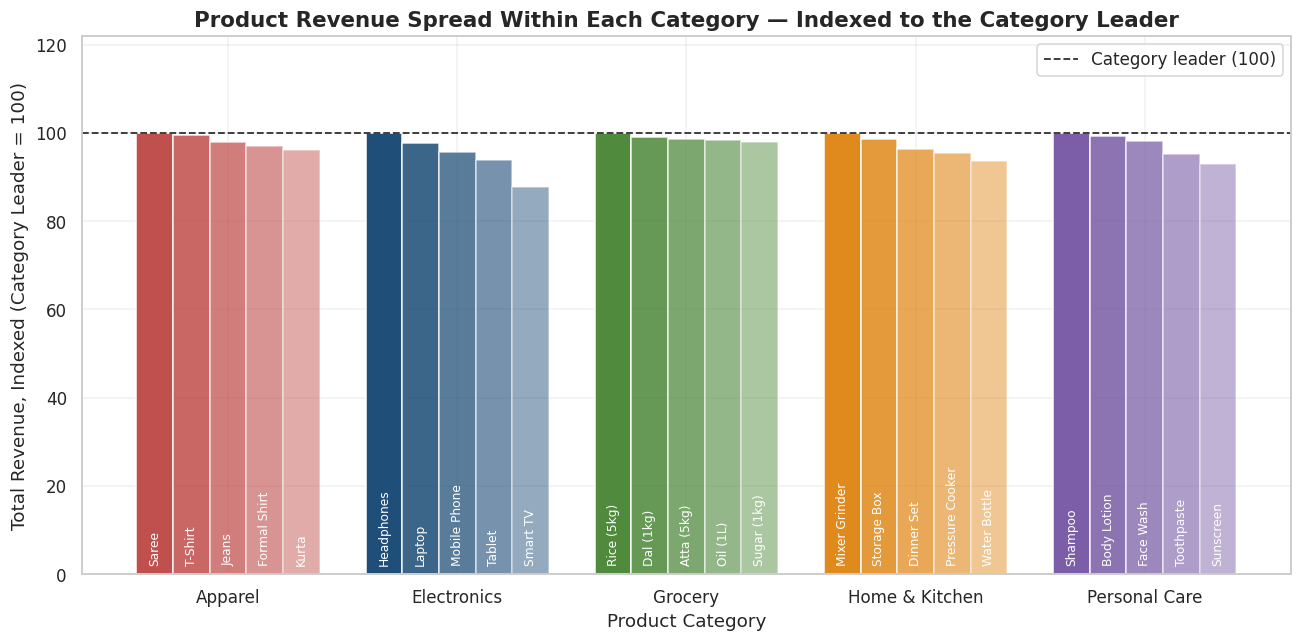

In [6]:
# Indexed against the strongest product in each category (100 = category leader), so the
# five categories can be compared on one axis despite very different revenue scales.
idx = product_perf.copy()
idx["index_vs_category_leader"] = (
    idx["total_revenue"] / idx.groupby("category")["total_revenue"].transform("max") * 100)

cats = sorted(idx["category"].unique())
fig, ax = plt.subplots(figsize=(12, 6))
width = 0.16
for k in range(5):                      # rank 1..5 within each category
    vals, labels = [], []
    for c in cats:
        sub = idx[idx["category"] == c].sort_values("total_revenue", ascending=False)
        vals.append(sub["index_vs_category_leader"].iloc[k])
        labels.append(sub["product_name"].iloc[k])
    pos = np.arange(len(cats)) + (k - 2) * width
    bars = ax.bar(pos, vals, width=width,
                  color=[CATEGORY_COLOURS[c] for c in cats],
                  alpha=1 - k * 0.13, edgecolor="white")
    for b, lab in zip(bars, labels):
        ax.text(b.get_x() + b.get_width()/2, 2, lab, rotation=90,
                ha="center", va="bottom", fontsize=8, color="white")

ax.axhline(100, color="#333333", linestyle="--", linewidth=1.2,
           label="Category leader (100)")
ax.set_title("Product Revenue Spread Within Each Category — Indexed to the Category Leader")
ax.set_xlabel("Product Category")
ax.set_ylabel("Total Revenue, Indexed (Category Leader = 100)")
ax.set_xticks(np.arange(len(cats)))
ax.set_xticklabels(cats)
ax.set_ylim(0, 122)
ax.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.show()

### Which category would we challenge, and why — [Mulla Javeed]

**What happened.** Within every category the five products sit remarkably close together. In Grocery
the weakest product (Sugar (1kg), ₹83.78 L) is **97.8% of the strongest** (Rice (5kg), ₹85.62 L); in
Apparel the weakest (Kurta, ₹1.36 Cr) is 96.1% of the strongest (Saree, ₹1.42 Cr). Even in
Electronics — where the rupee gap is by far the largest at **₹58.14 L** — the weakest product
(Smart TV, ₹4.19 Cr) still achieves 87.8% of the strongest (Headphones, ₹4.77 Cr).

**What that means.** There is **no single dead product dragging any category down**. The chain does
not have a delisting problem; it has a category-trajectory problem. That is an important finding to
carry into the meeting, because it removes the easy answer ("drop the worst SKU") and forces the real
conversation about category performance.

**The category we would challenge: Electronics.** The case is built on three numbers from this
dataset, not on assumption:

1. **Every Electronics product is declining.** Jan→Jun: Mobile Phone **−57.1%**, Tablet **−40.9%**,
   Laptop **−30.7%**, Smart TV **−21.9%**, Headphones **−20.3%**. When all five products fall
   together, the cause sits at category level — supply, pricing, range refresh or in-store
   execution — not with one weak line.
2. **The decline is a footfall decline, not a price decline.** Electronics transactions fell from
   **790 in January to 526 in June (−33.4%)** and units from 2,032 to 1,331, while the average unit
   price was essentially unchanged (₹24,183 in January vs ₹23,659 in June). The chain is not
   discounting its way down; it is simply selling to fewer buyers.
3. **The exposure is the largest in the business.** Electronics is **₹22.65 Cr, 49.3% of chain
   revenue**, so this is where a third of the shelf-space decision's value sits.

**The specific challenge to put on the table.** Lead with **Mobile Phone**, whose monthly revenue
fell from ₹98.03 L in January to **₹42.10 L in June, a 57.1% collapse** — the single sharpest product
decline anywhere in the dataset — and with **Smart TV at ₹4.19 Cr**, the lowest-revenue product in a
category whose products are otherwise near-identical in size. Ask the Electronics supplier to account
for the loss of 264 monthly transactions and to justify continued promotional investment against a
falling run rate.

*Note on scope: the dataset contains no supplier column, so we refer to categories and products
rather than naming supplier entities. The challenge should be directed at whoever supplies the
Electronics category.*

---